In [1]:
# suppress tensorflow logging, usually not useful unless you are having problems with tensorflow or accessing gpu
# it seems necessary to have this environment variable set before tensorflow is imported, or else it doesn't take effect
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 

# imports generally useful throughout the notebook
# usually all imports should happen at the top of a notebook, but in
# these notebooks where the purpose is to show how to use the Keras API
# the relevant imports will happen in the cells where the API is discussed
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# global settings for notebook output and images
plt.rcParams['figure.figsize'] = (8, 8) # set default figure size, 10in by 8in
np.set_printoptions(precision=4, suppress=True)

E0000 00:00:1748914933.895197   48519 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748914933.929368   48519 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1748914934.163892   48519 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1748914934.163949   48519 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1748914934.163952   48519 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1748914934.163953   48519 computation_placer.cc:177] computation placer already registered. Please check linka

In [2]:
# import project defined modules / functions used in this notebook
# ensure that the src directory where project modules are found is on
# the PYTHONPATH
import sys
sys.path.append("../src")

# assignment function imports for doctests and github autograding
# these are required for assignment autograding
from nndl import vectorize_samples, plot_history

In [3]:
# if want to restrict to cpu or gpu, configure visible device for rest of notebook to use
#dev = tf.config.list_physical_devices()
#print('Available Devices : ', dev)
#tf.config.set_visible_devices(dev[0], 'CPU')
#tf.config.set_visible_devices(dev[1], 'GPU')

# Chapter 5: Fundamentals of Machine Learning

Supporting materials for:

Chollet (2021). *Deep Learning with Python*. 2nd ed. Manning Publications Co.
[Amazon](https://www.amazon.com/Learning-Python-Second-Fran%C3%A7ois-Chollet/dp/1617296864/ref=sr_1_1?crid=32NFM2SBCJVQQ)

After the three practical examples from the previous unit, you should be starting to feel
familiar with how to approach classification and regression problems using neural networks.

You've also experienced some discussion on the central problem of machine learning: **overfitting**.

In this unit we will attempt to improve and formalize some of these intuitions about
machine learning into a solid conceptual framework.  Being good at building machine learning
models  means that you know how to accurately evaluate models, and how to balance between
training and generalization.


## 5.1 Generalization: The goal of machine learning

### 5.1.1 Underfitting and overfitting

At the beginning of training, optimization and generalization are correlated: the
lower the loss on training data, the lower the loss on test data. While this is happening,
your model is said to be **underfit**: there is still progress to be made

But after a certain number of iterations on the training data, generalization stops improving, validation metrics stall
and then begin to degrade: the model is starting to **overfit**.  Overfitting is particularly likely to occur when
your data is noisy, if it involves uncertainty, or if it includes rare features.  


Here’s a striking example. Take MNIST. Create a new training set by concatenating
784 white noise dimensions to the existing 784 dimensions of the data, so half of the
data is now noise. For comparison, also create an equivalent dataset by concatenating
784 all-zeros dimensions. Our concatenation of meaningless features does not at all
affect the information content of the data: we’re only adding something. Human classification
accuracy wouldn’t be affected by these transformations at all.

In [4]:
from tensorflow.keras.datasets import mnist

(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

train_images_with_noise_channels = np.concatenate(
    [train_images, np.random.random((len(train_images), 784))], axis=1)
train_images_with_zeros_channels = np.concatenate(
    [train_images, np.zeros((len(train_images), 784))], axis=1)

In [5]:
def get_model():
    model = keras.Sequential([
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])
    model.compile(optimizer="rmsprop",
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model

model = get_model()
history_noise = model.fit(
    train_images_with_noise_channels, train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2)

model = get_model()
history_zeros = model.fit(
    train_images_with_zeros_channels, train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2)

I0000 00:00:1748914941.523092   48519 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9706 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


Epoch 1/10


I0000 00:00:1748914952.899140   48623 service.cc:152] XLA service 0x7e6cf0018750 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1748914952.899924   48623 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
I0000 00:00:1748914953.121059   48623 cuda_dnn.cc:529] Loaded cuDNN version 90300


 57/375 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4169 - loss: 2.1156

I0000 00:00:1748914955.677142   48623 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.6981 - loss: 1.0190 - val_accuracy: 0.9249 - val_loss: 0.2578
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9165 - loss: 0.2708 - val_accuracy: 0.9395 - val_loss: 0.2006
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9474 - loss: 0.1739 - val_accuracy: 0.9539 - val_loss: 0.1577
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9631 - loss: 0.1210 - val_accuracy: 0.9603 - val_loss: 0.1356
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9737 - loss: 0.0876 - val_accuracy: 0.9563 - val_loss: 0.1529
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9796 - loss: 0.0649 - val_accuracy: 0.9553 - val_loss: 0.1531
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9863 - loss: 0.0447 - val_accuracy: 0.9470 - val_loss: 0.1935
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9885 - loss: 0.0364 - val_accuracy: 0.9551 - val

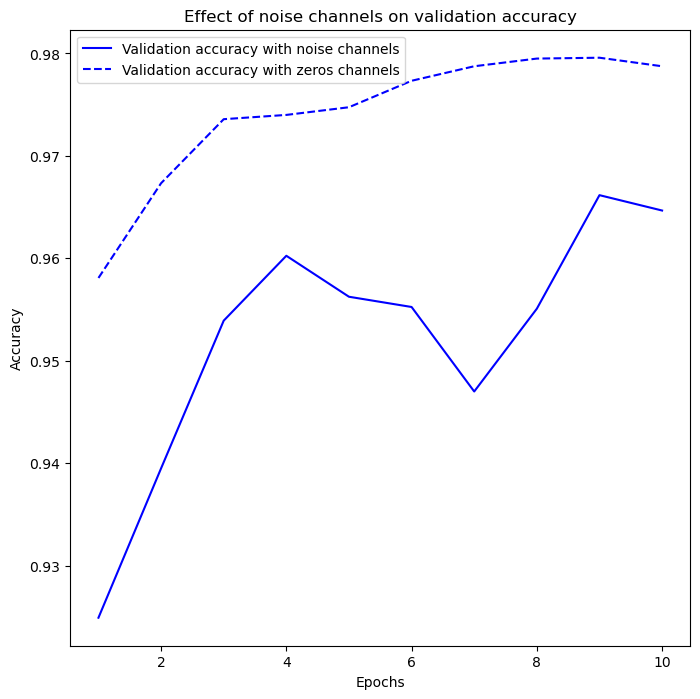

In [6]:
val_acc_noise = history_noise.history["val_accuracy"]
val_acc_zeros = history_zeros.history["val_accuracy"]
epochs = range(1, 11)
plt.plot(epochs, val_acc_noise, "b-",
         label="Validation accuracy with noise channels")
plt.plot(epochs, val_acc_zeros, "b--",
         label="Validation accuracy with zeros channels")
plt.title("Effect of noise channels on validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend();

Despite the data holding the same information in both cases, the validation accuracy
of the model trained with noise channels ends up about one percentage point lower, 
purely through the influence of spurious correlations. The more
noise channels you add, the further accuracy will degrade. 
**Noisy features inevitably lead to overfitting.**

As such, a common data exploration step in machine learning is to do a
**feature selection** or **feature importance** determination.  Restricting the
IMDB data to the top 10,000 most common words was a form of feature selection.
The typical way to do feature selection is to compute some usefulness score for each
feature available, a measure of how informative the feature is with respect to the
label.

### 5.1.2 The nature of generalization in deep learning

A remarkable fact about deep learning models is that they can be trained to fit anything,
as long as they have enough representational power.

Just to prove it, if you randomly shuffle the lables of the MNIST dataset and train a model
(of sufficient power) on that, the training loss will go down just fine and look normal.
The validation loss will not improve since there is no possibility of generalization for
random data.

In [7]:
# get the mnist training data
(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

# copy the labels and randomly shuffle them
random_train_labels = train_labels[:]
np.random.shuffle(random_train_labels)


model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

# the validation_split will split 20% of the data and use
# it for loss validation
history = model.fit(train_images, random_train_labels,
                    epochs=100,
                    batch_size=128,
                    validation_split=0.2)

Epoch 1/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.1027 - loss: 2.3308 - val_accuracy: 0.1016 - val_loss: 2.3047
Epoch 2/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1164 - loss: 2.2984 - val_accuracy: 0.1040 - val_loss: 2.3100
Epoch 3/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1287 - loss: 2.2892 - val_accuracy: 0.1108 - val_loss: 2.3116
Epoch 4/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1413 - loss: 2.2774 - val_accuracy: 0.1106 - val_loss: 2.3178
Epoch 5/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1562 - loss: 2.2601 - val_accuracy: 0.1064 - val_loss: 2.3300
Epoch 6/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1688 - loss: 2.2396 - val_accuracy: 0.1044 - val_loss: 2.3458
Epoch 7/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1817 - loss: 2.2179 - val_accuracy: 0.1028 - val_loss: 2.3596
Epoch 8/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1989 - loss: 2.1896 - val_accu

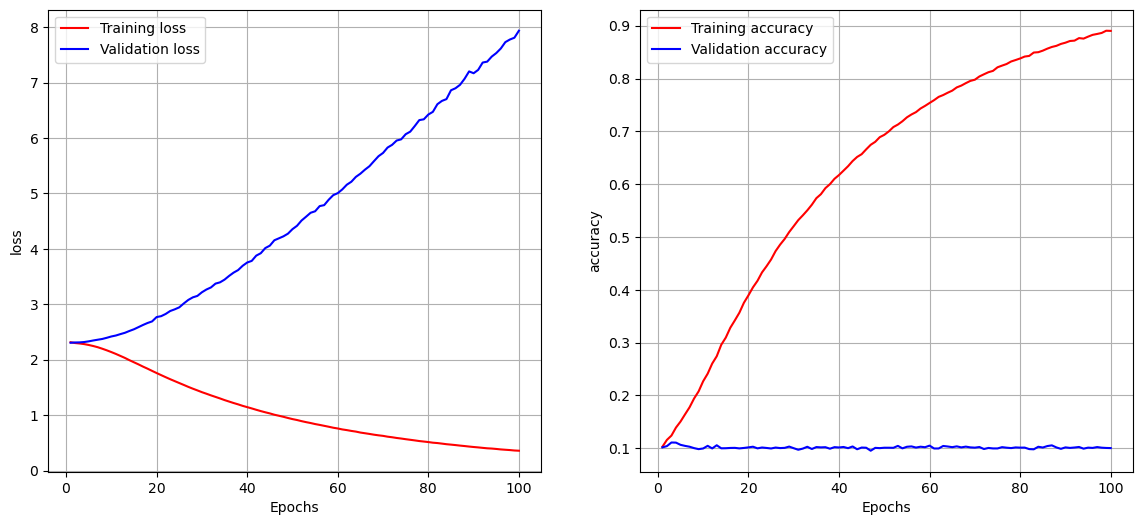

In [8]:
plt.figure(figsize=(14,6))
ax_loss = plt.subplot(1, 2, 1)
plot_history(ax_loss, history.history, 'loss')
ax_acc = plt.subplot(1, 2, 2)
plot_history(ax_acc, history.history, 'accuracy')

Training loss actually looks about the same as if you trained on real data.  Training accuracy is not as high as you would expect
to see on MNIST, because randomly shuffling the labels makes it tougher to find any actual patterns (it is only learning the noise in
the training data).

For data that has no information you migh see accuracy and loss curves like this.  For example though the accuracy improves on the data
it is learning the noise for, actual generalization accuracy on unseen validation data always remains at 10% or random guess
level.

How come deep learning models generalize at all? Shouldn’t
they just learn an ad hoc mapping between training inputs and targets, like a fancy
dict?  The nature of generalization in deep learning has rather little to do
with deep learning models themselves, and much to do with the structure of information
in the real world.

#### The manifold hypothesis

#### Interpolation as a source of generalization

#### Why deep learning works

#### Training data is paramount

## 5.2 Evaluating Machine Learning Models

You can only control what you can observe.

### 5.2.1 Training, validation and test sets

You train on the training data and evaluate your model while fitting it and while
comparing alternative models on the validation data. Once your model is ready for
prime time, you test it one final time on the test data, which is meant to be as
similar as possible to production data. Then you can deploy the model in production.

Developing a model always involves tuning its configuration.  You do this tuning by using
a feedback signal: the performance of the model on the validation data.  

Tuning the configuration of a model or multiple modles based on its performance
on the validation set can quickly result in *overfitting to the validation set*,
even though your model is never directly trained on it.  

But we care about performance on completely new data, not test data, and not the
validation data we are using to try and optimize the model architecture.  This is
why a completely different, never-before-seen dataset is needed to evaluate a
final model, the test dataset.

#### Simple holdout validation

In order to prevent information leaks, you shouldn’t tune your model based on the test set, and therefore you
should also reserve a validation set.

A simple implementaiton of holdout validation can be done as follows (this is random data, just for illustration).

```python
# data with 100,000 samples of 50 features for illustration
num_validation_samples = 10000
all_train_datadata = np.random.random((100000, 50))

# shuffling the data is usually appropriate, it could be sorted or orderd when you get it
# default behavior of np.random.shuffle on a tensor is to only shuffle the 0-th (sample) dimension
np.random.shuffle(all_train_data)


# define the validation set, slize the first 0-num_validation_samples from the data for validation
validation_data = all_train_data[:num_validation_samples]

# define the training set, use remaining data after split
train_data = all_train_datadata[num_validation_samples:]

# train a model on the training data and evaluatte it on the validation data
model = get_model()
model.fit(training_data, ...)
validation_score = model.evaluate(validation_data, ...)

# at this point you look at validation_score performance on validation data, and tune your
# model and model parameters.  Then retrain it and evaluate again, repeat
# as necessary until satisfied with performance

# once you've tuned your hyperparameters, its common to train your final
# model from stratch on all non-test data available
model = get_model()
model.fit(all_train_data, ...)
test_score = model.evaluate(test_data, ...)
```

#### K-fold validation

With this approach, you split your data into `K` partitions of equal size. For each partition
`i`, train a model on the remaining `K - 1` partitions, and evaluate it on partition `i`.
Your final score is then the averages of the K scores obtained.

This method is helpful when the performance of your model shows significant variance based on your train/test
split.

A simple pseudo code implementaiton by hand of K-fold validation looks like the following

```python
# data with 100,000 samples of 50 features for illustration
all_train_datadata = np.random.random((100000, 50))

# number of folds to divide data into
k = 3

# integer division will divide data into as equal sized partitions as possible, though
# last fold can have a few extra with this method
num_validation_samples = len(data) // k
```

In [9]:
# for instance, the size of the folds when we have around 100,000 samples would be
print(99999 // 3)  # all folds exactly equal in size
print(100000 // 3) # last fold has 1 extra sample
print(100001 // 3) # last fold has 2 extra samples
print(100002 // 3) # all folds exactly equal again

33333
33333
33333
33334


```python
# always a good idea to shuffle data in case it is sorted or ordered
np.random.shuffle(all_train_data)

# keep results for each fold validation to be reported and averged at end
validation_scores = []

# in k-fold validation, we perform a number of separate trainings of the model equal to k
for fold in range(k):
    # selects the validation-data partition from all of the data
    validation_data = data[num_validation_samples * fold: num_validation_samples * (fold + 1)]

    # combine remainder of the data for the training set
    training_data = np.concatenate(
        data[:num_validation_samples * fold],
        data[num_validation_samples * (fold + 1):]
    )

    # make sure you create a brand new instance of a model, can be easy to continue
    # training a previously trained model using keras if don't specificly create new model
    # with randomly initialized weights
    model = get_model()
    model.fit(training_data, ...)

    # use validation data to evaluate this fold
    validation_score = model.evaluate(validation_data, ...)
    validation_scores.append(validation_score)

# after k folds of training and evaluation on held back validation data,
# a better measure of generalization is the average of the individual validation scores
validation_score = np.average(validation_scores)

# train a new final model on all non-test data available and evaluate with the final test data
model = get_model()
model.fit(all_train_data, ...)
test_score = model.evaluate(test_data, ...)
```

#### Iterated K-fold validation with shuffling

This one is for situations in which you have relatively little data available and you need
to evaluate your model as precisely as possible. It consists of applying K-fold validation
`P` times, shuffling the data every time before splitting `K` ways.  The final score is the 
average of the `P` runs of K-fold validation.  Note that you end up training and
evaluation `P * K` models.

In essence, if you turned the K-fold validation code into a function that you could call, that would return
the average validation score as a result, and the function shuffled the data passed in each
time before dividing into folds, you could call this function `P` times to perform
iterated K-fold validation.

### 5.2.2 Beating a common-sense baseline

Before you start working with a dataset, you should always pick
a trivial baseline that you’ll try to beat.

### 5.2.3 Things to keep in mind about model evaluation

- **Data representativeness** You want both your training set and test set to be representative of the data at hand.
  For this reason you usually should at least **randomly shuffle** your data before splitting it into training and test sets.
- **The arrow of time** On the other hand, f you are doing time series prediction, you should **NOT** randomly shuffle your data
  before splitting it, this will cause **temporal leak**.  Instead always make sure all data in test set is *posterior* to the
  data in the training set.
- **Redundancy in your data** Be careful of repeated data points appearing multiple times in a dataset (not uncommon).  If you
  split a repeated sample and end up with it in the train and test set, you'll be leaking information and essentially testing
  with part of the data you trained with.

## 5.3 Improving model fit

To achieve the perfect fit, you must first overfit. Since you don’t know in advance
where the boundary lies, you must cross it to find it.

Thus your initial goal as you start on a problem is to achieve a model that shows some
generalization power and that is able to overfit.  Once you have such a model, you'll focus
on refining generalization by fighting overfitting.

There are 3 common problems you'll encounter when starting:

1. Training doesn’t get started: your training loss doesn’t go down over time.
2. Training gets started just fine, but your model doesn’t meaningfully generalize:
   you can’t beat the common-sense baseline you set.
3. Training and validation loss both go down over time, and you can beat your
   baseline, but you don’t seem to be able to overfit, which indicates you’re still
   underfitting.

### 5.3.1 Tuning key gradient descent parameters

Sometimes training doesn’t get started, or it stalls too early. Your loss is stuck. This is
always something you can overcome. When this happens, it’s always a problem with the configuration of the gradient
descent process: your choice of optimizer, the distribution of initial values in the
weights of your model, your learning rate, or your batch size. All these parameters are
interdependent, and as such it is usually sufficient to tune the learning rate and the
batch size while keeping the rest of the parameters constant.

Let's look at a concrete example of what we are talking about here.  Let's train MNIST model
from before with an inappropriately large learning rate value of 1.  The training loss might decrease
a bit, but it will quickly stop, and maybe even increase on the training data, which indicates
divergence.

In [10]:
(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])

# notice the parameter to RMSprop, this sets the learning rate to 1
model.compile(optimizer=keras.optimizers.RMSprop(1.),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

history = model.fit(train_images, train_labels,
                    epochs=50,
                    batch_size=128,
                    validation_split=0.2)

Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4073 - loss: 3400.9656 - val_accuracy: 0.1713 - val_loss: 2.2483
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1432 - loss: 2.6330 - val_accuracy: 0.1838 - val_loss: 2.2983
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1534 - loss: 3.1139 - val_accuracy: 0.1959 - val_loss: 2.1180
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1656 - loss: 2.7171 - val_accuracy: 0.1763 - val_loss: 2.2616
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1880 - loss: 2.3797 - val_accuracy: 0.1922 - val_loss: 2.2934
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1926 - loss: 2.2720 - val_accuracy: 0.1910 - val_loss: 2.1814
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1882 - loss: 2.2413 - val_accuracy: 0.2162 - val_loss: 2.4577
Epoch 8/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1932 - loss: 2.4784 - val_accuracy:

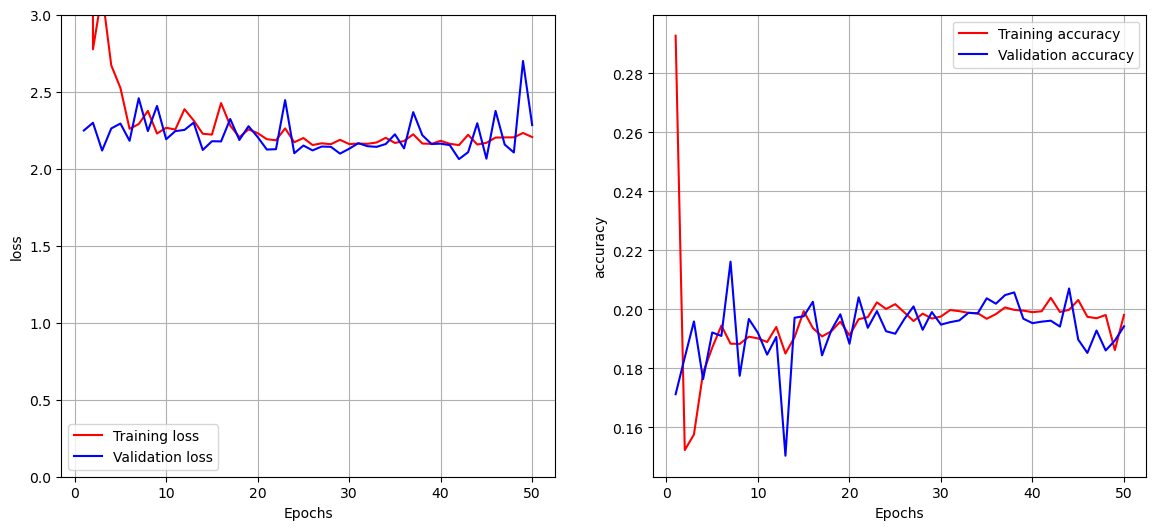

In [11]:
plt.figure(figsize=(14,6))
ax_loss = plt.subplot(1, 2, 1)
plot_history(ax_loss, history.history, 'loss')
ax_loss.set_ylim(0, 3) # clip yrange to better see loss
ax_acc = plt.subplot(1, 2, 2)
plot_history(ax_acc, history.history, 'accuracy')

The model quickly reaches a training validation accuracy in the 30% range, but cannot get past that.  Let's lower the learning rate to a
more reasonable value of `1e-2`.

In [12]:
model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation="softmax")
])

# only difference from before, set learning rate to 0.01
model.compile(optimizer=keras.optimizers.RMSprop(1e-2),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

history = model.fit(train_images, train_labels,
                    epochs=50,
                    batch_size=128,
                    validation_split=0.2)

Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8335 - loss: 0.8000 - val_accuracy: 0.9499 - val_loss: 0.1829
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9640 - loss: 0.1276 - val_accuracy: 0.9668 - val_loss: 0.1299
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9739 - loss: 0.0973 - val_accuracy: 0.9695 - val_loss: 0.1400
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9787 - loss: 0.0793 - val_accuracy: 0.9721 - val_loss: 0.1438
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9835 - loss: 0.0677 - val_accuracy: 0.9706 - val_loss: 0.1772
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9868 - loss: 0.0528 - val_accuracy: 0.9723 - val_loss: 0.1808
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9869 - loss: 0.0552 - val_accuracy: 0.9723 - val_loss: 0.2023
Epoch 8/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9892 - loss: 0.0461 - val_accuracy: 0.

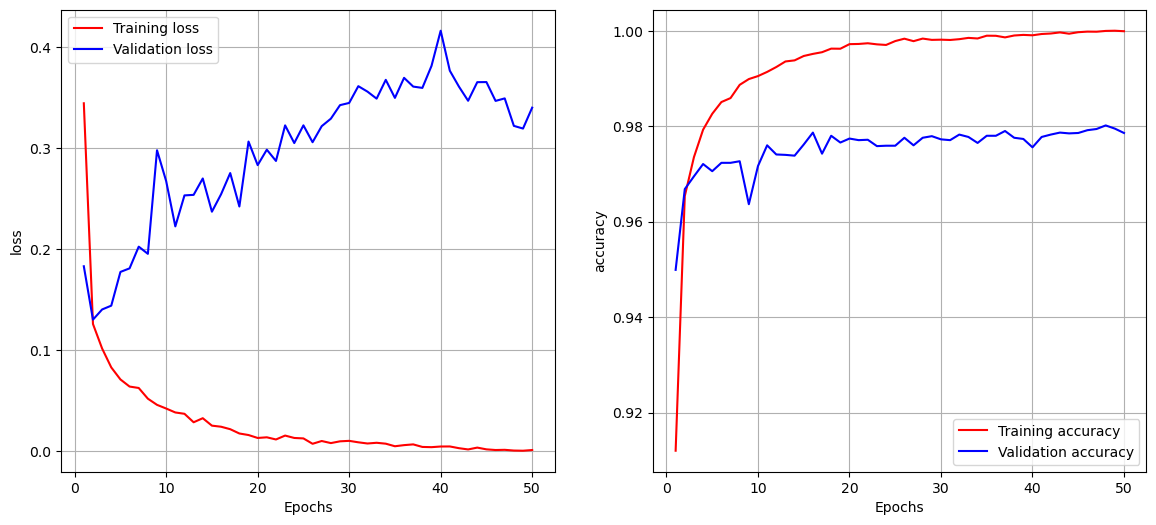

In [13]:
plt.figure(figsize=(14,6))
ax_loss = plt.subplot(1, 2, 1)
plot_history(ax_loss, history.history, 'loss')
#ax_loss.set_ylim(0, 3) # clip yrange to better see loss
ax_acc = plt.subplot(1, 2, 2)
plot_history(ax_acc, history.history, 'accuracy')

These learning curves look much more reasonable.  Not only is accuracy much better, but the training loss actually steadly decreases
for 30 epochs or so, indicating that it is fiting the data.

If you find yourself in a similar situation, try:

- Lowering or increasing the learning rate. A learning rate that is too high may
  lead to updates that vastly overshoot a proper fit, like in the preceding example,
  and a learning rate that is too low may make training so slow that it appears
  to stall.
- Increasing the batch size. A batch with more samples will lead to gradients that
  are more informative and less noisy (lower variance).

### 5.3.2 Leveraging better architecture priors

### 5.3.3 Increasing model capacity

If your model seems to be fitting the training data, and your validation metrics are going down and it seems to achieve at least some level
of generalization, then, you next need to get your model to start overfitting.

For example, consider using a simple logistic regression trained on MNIST dataset.

In [14]:
# remember that a logistic regression is really equivalent to a
# neural network with a single layer performing a tensor multiple
# of weight parameters and a tensor addition to the bias parameters
model = keras.Sequential([layers.Dense(10, activation="softmax")])

model.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

history_small_model = model.fit(train_images, train_labels,
                                epochs=20,
                                batch_size=128,
                                validation_split=0.2)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7357 - loss: 1.0433 - val_accuracy: 0.9015 - val_loss: 0.3617
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9001 - loss: 0.3649 - val_accuracy: 0.9137 - val_loss: 0.3100
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9103 - loss: 0.3221 - val_accuracy: 0.9176 - val_loss: 0.2929
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9156 - loss: 0.3035 - val_accuracy: 0.9207 - val_loss: 0.2847
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9194 - loss: 0.2915 - val_accuracy: 0.9235 - val_loss: 0.2784
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9214 - loss: 0.2791 - val_accuracy: 0.9245 - val_loss: 0.2759
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9212 - loss: 0.2774 - val_accuracy: 0.9252 - val_loss: 0.2724
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9218 - loss: 0.2793 - val_accuracy: 0.

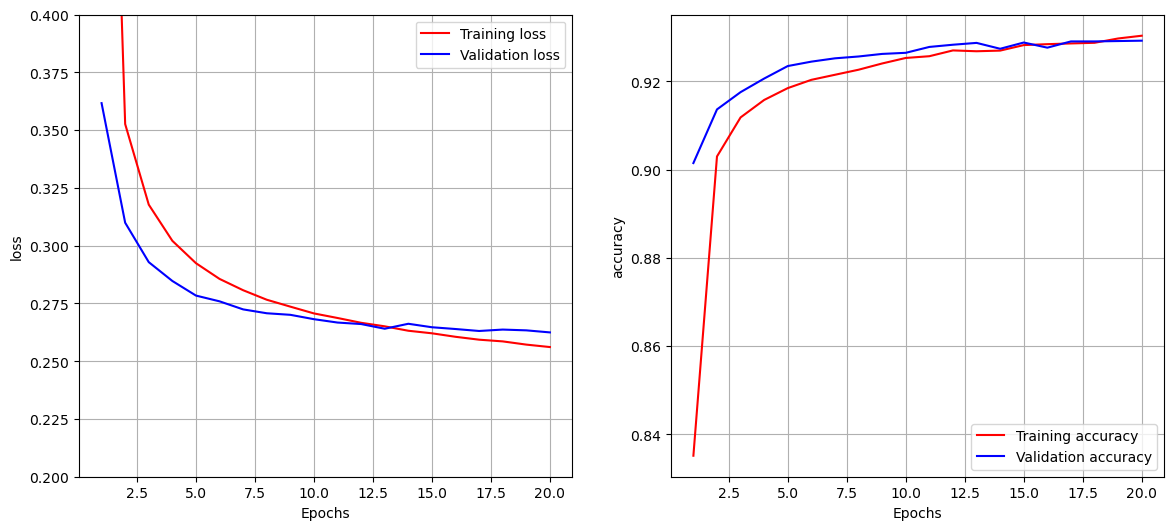

In [15]:
plt.figure(figsize=(14,6))
ax_loss = plt.subplot(1, 2, 1)
plot_history(ax_loss, history_small_model.history, 'loss')
ax_loss.set_ylim(0.2, 0.4) # clip yrange to better see loss
ax_acc = plt.subplot(1, 2, 2)
plot_history(ax_acc, history_small_model.history, 'accuracy')

What we are looking at here is the validation loss.  Validation loss seem to stall or are improving very slowly.
Instead if the model is sufficiently powerful, we would expect overfitting.  The validation loss
goes to 0.26 and just stays there.  You can fit, but you can't clearly overfit.

The sign of a model that is overfitting is that validation loss will go down to some minimum, but will begin to increase again
once overfitting begins to occur.  Remember that it should always be possible to overfit.  We saw that a neural
network can fit random data if you tell it to. If you can't seem to be able to overfit, it's likely a problem
with the **representational power** of your model. You need a bigger model with more **capacity**.

You can increate representational power by adding more layers, using bigger layers, or using kinds of
layers more appropriate to the problem.

For example, if we use a bigger model we can easily get the model to overfit.

In [16]:
model = keras.Sequential([
    layers.Dense(96, activation="relu"),
    layers.Dense(96, activation="relu"),
    layers.Dense(10, activation="softmax"),
])

model.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

history_large_model = model.fit(
    train_images, train_labels,
    epochs=40,
    batch_size=128,
    validation_split=0.2)

Epoch 1/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.8354 - loss: 0.6088 - val_accuracy: 0.9441 - val_loss: 0.1929
Epoch 2/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9502 - loss: 0.1751 - val_accuracy: 0.9601 - val_loss: 0.1415
Epoch 3/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9658 - loss: 0.1196 - val_accuracy: 0.9674 - val_loss: 0.1167
Epoch 4/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9731 - loss: 0.0917 - val_accuracy: 0.9677 - val_loss: 0.1089
Epoch 5/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9783 - loss: 0.0694 - val_accuracy: 0.9722 - val_loss: 0.0942
Epoch 6/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9832 - loss: 0.0570 - val_accuracy: 0.9732 - val_loss: 0.0910
Epoch 7/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9857 - loss: 0.0469 - val_accuracy: 0.9712 - val_loss: 0.0938
Epoch 8/40
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9876 - loss: 0.0387 - val_accuracy: 0

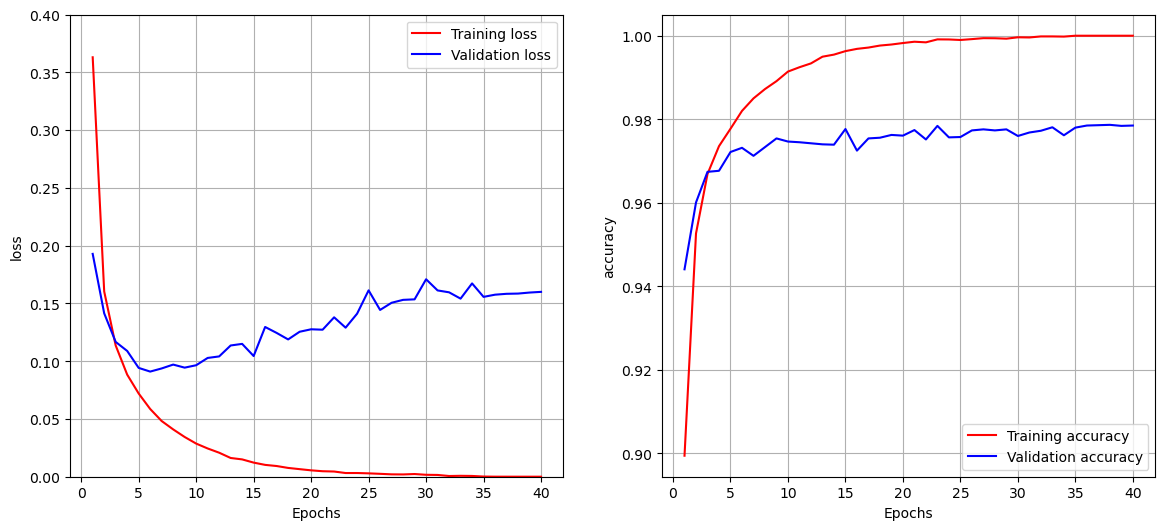

In [17]:
plt.figure(figsize=(14,6))
ax_loss = plt.subplot(1, 2, 1)
plot_history(ax_loss, history_large_model.history, 'loss')
ax_loss.set_ylim(0.00, 0.4) # clip yrange to better see loss
ax_acc = plt.subplot(1, 2, 2)
plot_history(ax_acc, history_large_model.history, 'accuracy')

The validation loss for a model with appropriate capacity looks something like the loss figure here.  
Training loss continues to improve steadily.  But validation loss decreases till epoch 5 to 10,
then clearly begins to creep back up again.  The model is overfitting here, learning the
noise in the data which decreases generalization.

## 5.4 Improving generalization

Once your model has shown itself to have some generalization power and to be able
to overfit, it’s time to switch your focus to maximizing generalization

### 5.4.1 Dataset curation

### 5.4.2 Feature engineering

### 5.4.3 Using early stopping

### 5.4.4 Regularizing your model


#### Reducing the network's size

